In [13]:
#Charger les données nettoyées
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

PROCESSED_DIR = Path("../data/processed")

jobs = pd.read_csv(
    PROCESSED_DIR / "clean_jobs.csv",
    low_memory=False
)

print(jobs.shape)
display(jobs.head())

(48563, 9)


,job_title,description,company,location,salary,description_clean,skills,skills_count,skills_text
0,marketing coordinator,Job descriptionA leading real estate firm in N...,Corcoran Sawyer Smith,"Princeton, NJ",38480.0,job descriptiona leading real estate firm in n...,[],0,NaN
1,mental health therapist/counselor,"At Aspen Therapy and Wellness , we are committ...",unknown,"Fort Collins, CO",83200.0,"at aspen therapy and wellness , we are committ...",[],0,NaN
2,assitant restaurant manager,The National Exemplar is accepting application...,The National Exemplar,"Cincinnati, OH",55000.0,the national exemplar is accepting application...,[],0,NaN
3,senior elder law / trusts and estates associat...,Senior Associate Attorney - Elder Law / Trusts...,"Abrams Fensterman, LLP","New Hyde Park, NY",157500.0,senior associate attorney - elder law / trusts...,[],0,NaN
4,service technician,Looking for HVAC service tech with experience ...,unknown,"Burlington, IA",70000.0,looking for hvac service tech with experience ...,[],0,NaN


In [14]:
#Vérifier la qualité
quality_report = pd.DataFrame({
    "type": jobs.dtypes.astype(str),
    "missing": jobs.isnull().sum(),
    "missing_percent": (
        jobs.isnull().mean() * 100
    ).round(2),
    "unique_values": jobs.nunique()
})

display(quality_report)

,type,missing,missing_percent,unique_values
job_title,object,0,0.00,30756
description,object,2,0.00,44387
company,object,0,0.00,13353
location,object,0,0.00,5713
salary,float64,34132,70.28,3607
description_clean,object,7,0.01,44289
skills,object,0,0.00,2266
skills_count,int64,0,0.00,21
skills_text,object,34384,70.80,2265


In [15]:
#Doublons
print("Doublons :", jobs.duplicated().sum())

Doublons : 4


In [16]:
#Offres sans compétence
without_skills = jobs[
    jobs["skills_count"] == 0
]

print(
    "Offres sans compétences détectées :",
    len(without_skills)
)

print(
    "Pourcentage :",
    round(
        len(without_skills) / len(jobs) * 100,
        2
    ),
    "%"
)

Offres sans compétences détectées : 34384
Pourcentage : 70.8 %


In [11]:
#Analyser les compétences les plus demandées
skills_series = (
    jobs["skills_text"]
    .fillna("")
    .str.split(", ")
    .explode()
)

skills_series = skills_series[
    skills_series != ""
]

top_skills = (
    skills_series
    .value_counts()
    .head(20)
    .reset_index()
)

top_skills.columns = [
    "skill",
    "job_count"
]

display(top_skills)

,skill,job_count
0,excel,6986
1,r,1967
2,sql,1954
3,python,1692
4,aws,1299
5,forecasting,1140
6,azure,1135
7,java,1070
8,oracle,893
9,statistics,741


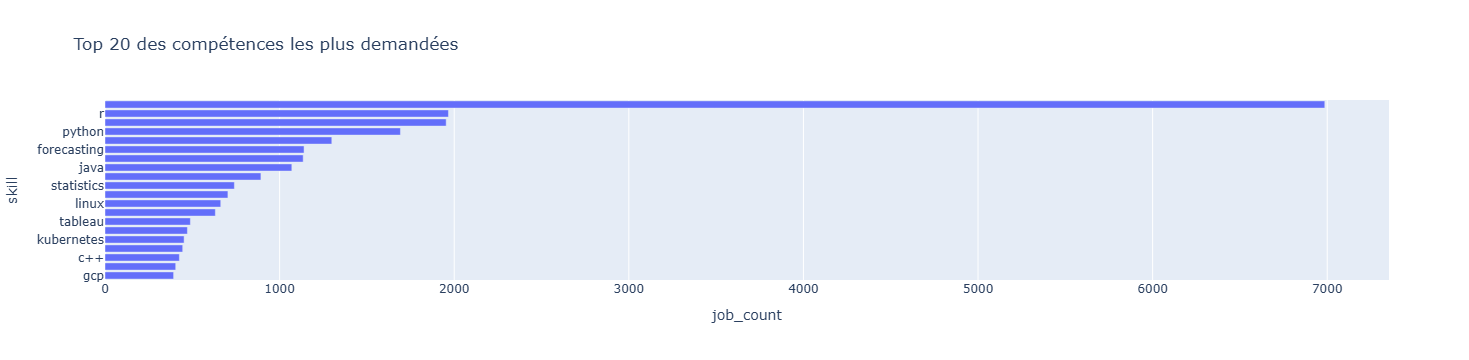

In [12]:
fig = px.bar(
    top_skills.sort_values("job_count"),
    x="job_count",
    y="skill",
    orientation="h",
    title="Top 20 des compétences les plus demandées"
)

fig.show()

In [9]:
#Analyser les métiers
top_jobs = (
    jobs["job_title"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_jobs.columns = [
    "job_title",
    "job_count"
]

display(top_jobs)

,job_title,job_count
0,sales manager,336
1,project manager,154
2,receptionist,142
3,assistant store manager,132
4,registered nurse - rn - ltac,122
5,senior accountant,110
6,administrative assistant,106
7,executive assistant,97
8,salesperson,96
9,customer service representative,94


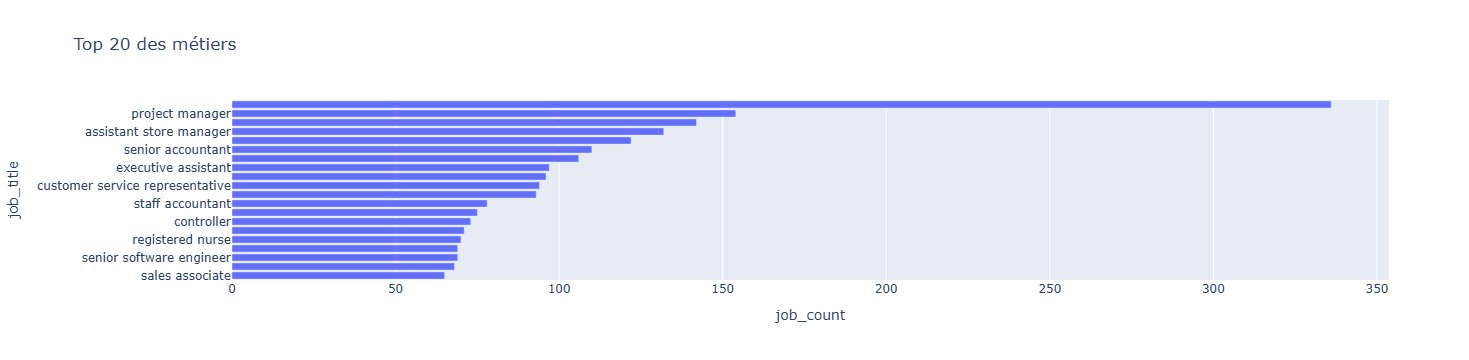

In [10]:
fig = px.bar(
    top_jobs.sort_values("job_count"),
    x="job_count",
    y="job_title",
    orientation="h",
    title="Top 20 des métiers"
)

fig.show()